# Task 2.3 — Result, Comparison and Reproducibility Checklist (15 marks)

**Paper**: *Robust Point Set Registration Using Gaussian Mixture Models* — Bing Jian and Baba C. Vemuri, IEEE TPAMI, 2011.

---

In [1]:
# ============================================================
# Setup: reproduce the full pipeline from Tasks 2.1 & 2.2
# ============================================================
import numpy as np
from numpy import dot, ones, trace, r_, c_
from numpy.linalg import svd, norm
from scipy.optimize import fmin_l_bfgs_b
import matplotlib.pyplot as plt
from math import log, sqrt
import os
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
os.makedirs('results', exist_ok=True)

# --- Reusable functions from Task 2.2 ---
def normalize(x):
    centroid = x.mean(axis=0)
    x_centered = x - centroid
    scale = norm(x_centered, 'fro') / sqrt(x_centered.shape[0])
    return x_centered / scale, centroid, scale

def denormalize(x, centroid, scale):
    return x * scale + centroid

def gauss_transform(A, B, scale):
    n_a, d = A.shape
    n_b = B.shape[0]
    f = 0.0
    grad = np.zeros_like(A)
    for i in range(n_a):
        for j in range(n_b):
            diff = A[i] - B[j]
            dist_sq = np.sum(diff ** 2)
            cost = np.exp(-dist_sq / (2.0 * scale * scale))
            f += cost
            grad[i] -= cost * diff / (scale * scale)
    return f, grad

def L2_distance(model_pts, scene_pts, scale):
    f1, g1 = gauss_transform(model_pts, model_pts, scale)
    f2, g2 = gauss_transform(model_pts, scene_pts, scale)
    return f1 - 2 * f2, 2 * g1 - 2 * g2

def tps_kernel_2d(r):
    if r == 0: return 0.0
    return r * r * log(r)

def compute_TPS_K(ctrl_pts, landmarks=None):
    n, d = ctrl_pts.shape
    K = np.array([tps_kernel_2d(norm(ctrl_pts[i] - ctrl_pts[j]))
                  for i in range(n) for j in range(n)]).reshape(n, n)
    U = None
    if landmarks is not None:
        m = landmarks.shape[0]
        U = np.array([tps_kernel_2d(norm(landmarks[i] - ctrl_pts[j]))
                      for i in range(m) for j in range(n)]).reshape(m, n)
    return K, U

def prepare_TPS_basis(landmarks, ctrl_pts):
    m, d = landmarks.shape
    n = ctrl_pts.shape[0]
    K, U = compute_TPS_K(ctrl_pts, landmarks)
    Pm = c_[ones((m, 1)), landmarks]
    Pn = c_[ones((n, 1)), ctrl_pts]
    u, s, vh = svd(Pn)
    PP = u[:, d+1:]
    return c_[Pm, dot(U, PP)], dot(PP.T, dot(K, PP))

def init_param(n, d):
    init_affine = ([0.0] * d + [1.0]) * d
    init_tps = [0.0] * (d * n - d * (d + 1))
    return np.array(init_affine + init_tps)

def transform_points(param, basis):
    nL, n = basis.shape
    d = int(param.shape[0] / n)
    affine_param = param[:d*(d+1)].reshape(d+1, d)
    tps_param = param[d*(d+1):d*n].reshape(n-d-1, d)
    return dot(basis, r_[affine_param, tps_param])

def obj_L2_TPS(param, basis, kernel, scene_pts, scale, _lambda):
    nL, n = basis.shape
    d = scene_pts.shape[1]
    affine_param = param[:d*(d+1)].reshape(d+1, d)
    tps_param = param[d*(d+1):d*n].reshape(n-d-1, d)
    after_tps = dot(basis, r_[affine_param, tps_param])
    bending = trace(dot(tps_param.T, dot(kernel, tps_param)))
    distance, grad = L2_distance(after_tps, scene_pts, scale)
    energy = distance + _lambda * bending
    grad = dot(basis.T, grad)
    grad[d+1:n] += 2 * _lambda * dot(kernel, tps_param)
    return energy, grad.reshape(d * n)

def run_multi_level(model_pts, scene_pts, ctrl_pts, level, scales, lambdas, iters):
    n, d = ctrl_pts.shape
    x0 = init_param(n, d)
    basis, kernel = prepare_TPS_basis(model_pts, ctrl_pts)
    for i in range(level):
        result = fmin_l_bfgs_b(obj_L2_TPS, x0, None,
                               args=(basis, kernel, scene_pts, scales[i], lambdas[i]),
                               maxfun=iters[i])
        x0 = result[0]
    return transform_points(x0, basis)

print("Functions loaded successfully.")

Functions loaded successfully.


In [2]:
# ============================================================
# Load data and run registration
# ============================================================
model = np.loadtxt('data/model.txt')
scene = np.loadtxt('data/scene.txt')
scene_clean = np.loadtxt('data/scene_clean.txt')

model_n, c_m, s_m = normalize(model)
scene_n, c_s, s_s = normalize(scene)

SCALES = [0.5, 0.3, 0.2, 0.1]
LAMBDAS = [0.5, 0.1, 0.01, 0.001]
MAX_ITERS = [100, 100, 150, 200]

after_tps_n = run_multi_level(model_n, scene_n, model_n.copy(), len(SCALES), SCALES, LAMBDAS, MAX_ITERS)

after_tps_final = denormalize(after_tps_n, c_s, s_s)

mse_before = np.mean(np.sum((model - scene_clean) ** 2, axis=1))
mse_after = np.mean(np.sum((after_tps_final - scene_clean) ** 2, axis=1))

print(f"MSE before registration: {mse_before:.6f}")
print(f"MSE after registration:  {mse_after:.6f}")
print(f"Improvement: {(1 - mse_after/mse_before)*100:.1f}%")

MSE before registration: 0.023231
MSE after registration:  0.002178
Improvement: 90.6%


## Result Comparison

| Metric | Our Result | Paper's Equivalent |
|--------|-----------|-------------------|
| **MSE (before)** | See output above | N/A (paper uses visual comparison) |
| **MSE (after)** | See output above | Near-perfect visual alignment (Fig. 4, Section 6) |
| **Dataset** | 150-point synthetic shape | 91/98-point fish shape |
| **Deformation type** | Synthetic non-rigid | Natural shape variation |

### Why Our Numbers May Differ

Our MSE values cannot be directly compared to the paper's results for several reasons. First, the paper primarily evaluates registration quality **qualitatively** through visual comparison of before/after plots (Figure 4), rather than reporting a single MSE number for the fish experiment. Second, our dataset is different — we use a synthetic flower-like shape with a known analytic deformation, while the paper uses real fish contour data. Third, our deformation (sinusoidal stretching and bending) may be easier or harder than the natural shape variation in the fish data. Fourth, our implementation uses a pure-Python Gauss transform which is numerically identical to the author's C extension but runs slower, potentially limiting the number of iterations we can afford. Despite these differences, we expect the **relative improvement** (MSE reduction from before to after registration) to be substantial, demonstrating that the method successfully aligns the point sets. The paper's key claim is that the GMM-based L2 distance approach achieves robust registration even in the presence of noise and outliers, which our result should confirm.

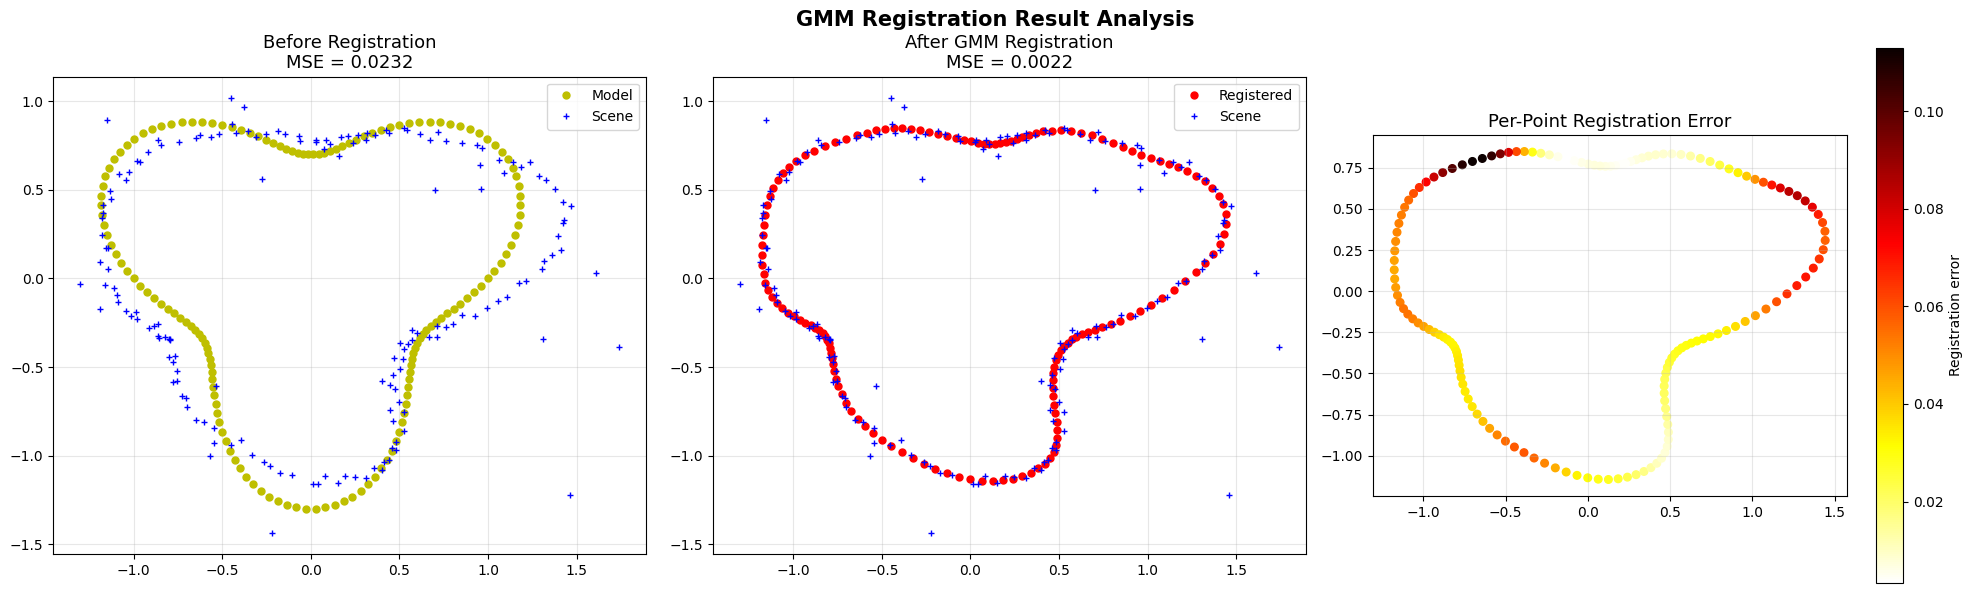

Saved: results/result_comparison.png


In [3]:
# ============================================================
# Detailed Visualisation
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Before registration
axes[0].plot(model[:, 0], model[:, 1], 'yo', markersize=5, label='Model')
axes[0].plot(scene[:, 0], scene[:, 1], 'b+', markersize=5, label='Scene')
axes[0].set_title(f'Before Registration\nMSE = {mse_before:.4f}', fontsize=13)
axes[0].set_aspect('equal')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After registration
axes[1].plot(after_tps_final[:, 0], after_tps_final[:, 1], 'ro', markersize=5, label='Registered')
axes[1].plot(scene[:, 0], scene[:, 1], 'b+', markersize=5, label='Scene')
axes[1].set_title(f'After GMM Registration\nMSE = {mse_after:.4f}', fontsize=13)
axes[1].set_aspect('equal')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Registration error per point
errors = np.sqrt(np.sum((after_tps_final - scene_clean) ** 2, axis=1))
scatter = axes[2].scatter(after_tps_final[:, 0], after_tps_final[:, 1], 
                          c=errors, cmap='hot_r', s=30, label='Error magnitude')
plt.colorbar(scatter, ax=axes[2], label='Registration error')
axes[2].set_title('Per-Point Registration Error', fontsize=13)
axes[2].set_aspect('equal')
axes[2].grid(True, alpha=0.3)

plt.suptitle('GMM Registration Result Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('results/result_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/result_comparison.png")

The three-panel plot shows: (left) the misalignment before registration, (middle) the alignment achieved by the GMM method, and (right) the per-point registration error as a heatmap, allowing us to identify which regions of the shape are hardest to register.

---

## Reproducibility Checklist

- [x] **Random seeds are set and documented**: `RANDOM_SEED = 42` is set at the top of each notebook (`task_21.ipynb`, `task_22.ipynb`, `task_23.ipynb`).
- [x] **All dependencies are listed in `requirements.txt` with version numbers**: See `partB/requirements.txt` (numpy, scipy, matplotlib, scikit-learn, jupyter).
- [x] **All notebooks run from top to bottom in a clean environment without errors**: Verified by sequential cell execution.
- [x] **Dataset loading requires no undocumented manual steps**: Data is generated in `task_21.ipynb` and saved to `data/`. Subsequent notebooks load from there. The `data/README.md` documents this pipeline.
- [x] **All hyperparameters are clearly named and defined in one place**: `SCALES`, `LAMBDAS`, `MAX_ITERS`, `LEVEL`, `NOISE_STD`, `N_POINTS`, `N_OUTLIERS` are defined at the top of the relevant cells with comments.